# Sistemas de ecuaciones

Consideremos el sistema:

$$x + y =3$$
$$3x - 4y = 2$$

Desde el punto de vista geomético la solución a este sistema es el punto de corte entre ambas rectas

<center>

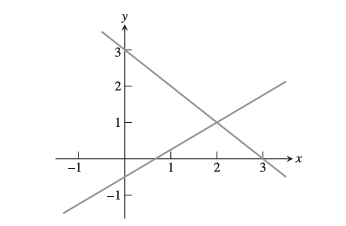

<center>

Para resolver este sistema es posible hacer uso del algoritmo de **eliminación gaussiana**. Se busca llevar la parte de la matriz que contiene los coeficientes del sistema de ecuaciones lineales a una forma triangular superior. Luego solo debe sustituirse hacia atrás

La etapa de eliminación consiste en conseguir los ceros de la parte inferior de la matriz, esto toma

```
for j in range(n-1):
        poner ceros en cada columna j
````

Ahora, hacer esta operación para cada columna implica, por ejemplo para la primera columna, poner ceros en $a_{21},...a_{n1}$

```
for j in range(n-1):
        for i in range(j+1, n):
                eliminar entrada a(i,j)
````

Las entradas princiales de cada columna que no son cero se denominan pivotes.

Eliminar cada entrada $a_{in}$ requiere 2n + 1 operaciones (una división, una n multiplicaciones y n sumas)

Hacerlo para cada columna requiere hacerlo n - 1 veces.

<center>

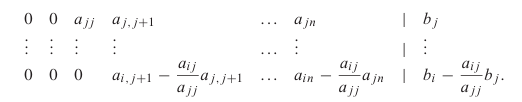

<center>




Considerando podemos ahorrarnos las operaciones por cero, necesitamos para cada elemento $a_{ij}$, una división, n - j + 1 multiplicaciones y n - j + 1 sumas/restas.

In [35]:
import numpy as np

# Por el momento no se consideran intercambios de filas
# Matrices de n ecuaciones y n incognitas

matriz = np.array([[2,2,3],[2,4,3],[1,2,3]], dtype = float)
b = np.array([[2],[1],[4]], dtype=float)

n = matriz.shape[1]-1

for j in range(n):
    if abs(matriz[j,j]) < 1e-15:
        print('Error pivote cero')
        break
    
    for i in range(j+1, n + 1):
        print(i,j+1)
        
        mult = matriz[i,j]/matriz[j,j]
        
        # Aunque esta parte parezca un error
        # Hacerlo de esta manera es eficiente puesto que no necesitamos
        # Hacer ninguna operación sobre el elemento a_ij posteriormente
        
        matriz[i,j+1:] = matriz[i,j+1:] - mult*matriz[j,j+1:]

        
        b[i] = b[i] - mult*b[j]

print(matriz)
print(b)



1 1
2 1
2 2
[[2.  2.  3. ]
 [2.  2.  0. ]
 [1.  1.  1.5]]
[[ 2. ]
 [-1. ]
 [ 3.5]]


In [36]:
sol = np.zeros((n+1,1))

for i in range(n,-1,-1):
    sol[i] = b[i]

    for j in range(n,i,-1):

        sol[i] -= matriz[i,j]*sol[j]

    sol[i] = sol[i]/matriz[i,i]



print(sol)

[[-2.        ]
 [-0.5       ]
 [ 2.33333333]]


El número total de operaciones necesarias para la eliminación es de 

$$\sum_{j=1}^{n-1} \sum_{i=1}^{j} 2(j+1)+1 = \frac{2}{3}n^3 + \frac{1}{2}n^2 - \frac{7}{6}n \approx \frac{2}{3}n^3$$

Al terminar obtenemos el siguiente sistema:

<center>

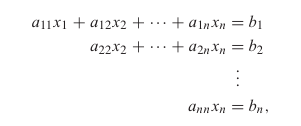

<center>

Para obtener las soluciones con sustitución hacia atrás:

$$x_n = \frac{b_n}{a_{nn}}$$
Y sustituyendo hasta:
$$x_1 = \frac{b_1 - a_{1n}x_n - ... - a_{12}x_2}{a_{11}}$$

La cantidad de operaciones son:

$$1 + 3 + 5 + ... + (2n - 1) = \sum_{i = 1}^n 2i - 1 = n^2$$

En conclusión podríamos decir que la eliminación gaussiana toma aproximadamente $\frac{2}{3}n^3$ operaciones o en notación de Big O, $O(n^3)$

# La factorización LU

Un sistema $Ax = b$ puede escribirse como:

$$
\begin{bmatrix} 1 & 1 \\ 3 & -4 \\ \end{bmatrix} \begin{bmatrix} x1 \\ x2\end{bmatrix} = \begin{bmatrix} 3 \\ 2 \end{bmatrix}
$$

La matriz de coefientes es $A$ y el vector del lado derecho es $b$.
Se desea encontrar un $x$ tal que el vector $Ax$ sea el vector $b$.
O en otras palabras, que $Ax$ y $b$ coincidan en todas su componentes.

La factorización $LU$ consiste en escribir a la matriz de coeficientes A, como un producto de una matriz triangular inferior $L$ y una matriz triangular superior $U$. Fragmenta un objeto complicado en varias partes.

Un ejemplo sería:

$$\begin{bmatrix} 1 & 1 \\ 3 & -4 \end{bmatrix} = \begin{bmatrix} 1 & 1 \\ 0 & -7 \end{bmatrix} = U$$

Lo que se hizo fue lleva a la matrix a su forma escalonada, esta será la parte $U$ de la factorización.
 Ahora $L$ será una matriz con unos en la diagonal y que guarda los coeficientes correspondientes a las multiplicaciones hechas al pivote para generar ceros en la matriz $A$. En este caso, para llevar a $A$ a la forma escalonada lo que se hizo fue multiplicar 3 a la primera fila y luego restarla a la segunda. Por lo tanto en la primera entrada de la segunda fila colocamos 3.

 $$\begin{bmatrix} 1 & 0 \\ 3 & 1 \end{bmatrix}$$

Si se hacen más operaciones el procedimiento es análogo.

Y llegamos a:

$$\begin{bmatrix} 1 & 0 \\ 3 & 1 \end{bmatrix} \begin{bmatrix} 1 & 1 \\ 0 & -7 \end{bmatrix} = \begin{bmatrix} 1 & 1 \\ 3 & -4 \end{bmatrix} = A$$



Esto funciona por 3 hechos fundamentales:

Sea $L_{ij}(-c)$ la matriz triangular inferior, cuyas únicas entradas diferentes de cero son unos en la diagonal principal y -c en la posición (i,j). Entonces $A \rightarrow L_{ij}(-c)A$ representa la operación por reglón restar c veces el renglón j del renglón i.

<center>

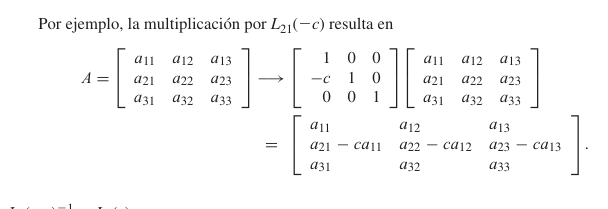

<center>

Además $L_{ij}(-c)^{-1} = L_{ij}(c)$

Entonces esto el ejemplo dado de la factorización LU puede entenderse como:
$$L_{21}(-3)A = \begin{bmatrix} 1 & 1 \\ 0 & -7 \end{bmatrix} = U$$

Luego, entonces como $L_{ij}(-c)^-1 = L_{ij}(c)$:

$$L_{21}(-3)A = U$$
$$L_{21}(-c)^{-1}L_{21}(-3)A = L_{21}(-c)^{-1}U$$
$$IA = L_{21}(-c)^-1U$$
$$A = L_{21}(-c)^-1U = LU$$



Y luego para generalizar todas las operaciones de resta se usa el siguiente hecho:

<center>

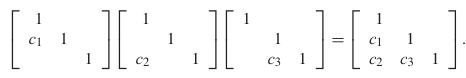

<center>

Ahora, como se conocen $L$ y $U$, problema $Ax = b$ puede expresarse como $LUx = b$. Definiendo el vector auxiliar $c = Ux$. Entonces la sustitución atrás consiste en:

1. Resolver $Lc = b$ para $c$ 
2. Resolver $Ux = c$ para $x$

$$\begin{bmatrix} 1 & 1 \\ 3 & -4 \end{bmatrix} = LU = \begin{bmatrix} 1 & 0 \\ 3 & 1 \end{bmatrix} \begin{bmatrix} 1 & 1 \\ 0 & -7 \end{bmatrix}$$

Resolver $Lc = b$ para por ejemplo $b = [3,2]$ se resumen en:

$$\begin{bmatrix} 1 & 0 \\ 3 & 1 \end{bmatrix} \begin{bmatrix} c_{11} \\ c_{21} \end{bmatrix} = \begin{bmatrix} 3 \\ 2 \end{bmatrix}$$

Y resolver $Ux = c$:

$$\begin{bmatrix} 1 & 1 \\ 0 & -7 \end{bmatrix} \begin{bmatrix} x_{11} \\ x_{21} \end{bmatrix} = \begin{bmatrix} c_{11} \\ c_{21} \end{bmatrix}$$

$$c_{11} = 3$$
$$3c_{11} + c_{21} = 2$$
$$c_{21} = 2 - 3(3) = -7$$

$$\begin{bmatrix} 1 & 1 \\ 0 & -7 \end{bmatrix} \begin{bmatrix} x_{11} \\ x_{21} \end{bmatrix} = \begin{bmatrix} 3 \\ -7 \end{bmatrix}$$

$$ x_{11} + x_{21} = 3$$
$$ -7x_{21} = -7$$
$$ x_{21} = 1$$
$$ x_{11} = 3 - 1 = 2$$